In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("Telco-Customer-Churn.csv")

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Encode categorical
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Build 3 Classification Models (Logistic Regression, Random Forest, Gradient Boosting)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier()
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


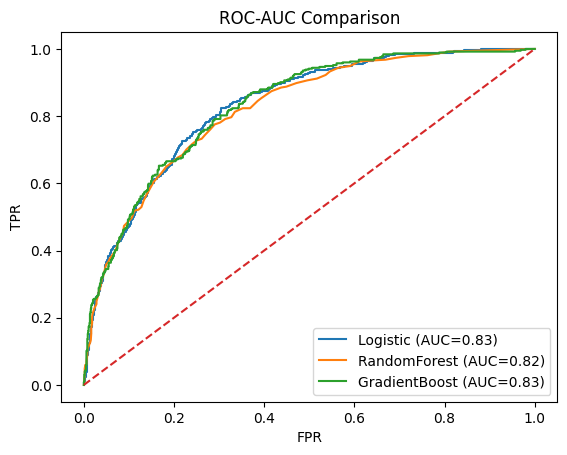

In [ ]:
# ROC-AUC Comparison
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC-AUC Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
# Select Champion Model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Champion Model:", best_model_name)

Champion Model: GradientBoost


In [ ]:
# Predict Churn Probability
churn_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
# CLV Prediction (Linear Regression)
from sklearn.linear_model import LinearRegression

y_clv = df['TotalCharges']

X_train_clv, X_test_clv, y_train_clv, y_test_clv = train_test_split(
    X, y_clv, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train_clv, y_train_clv)

clv_pred = lr.predict(X_test_clv)

In [ ]:
# Build Final Data Pipeline Output
final_df = pd.DataFrame(X_test)

final_df['Churn_Probability'] = churn_prob
final_df['Predicted_CLV'] = clv_pred

final_df.to_csv("final_telco_pipeline.csv", index=False)